# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros

## Pablo Medina y Santiago Serrano

Este notebook consolida las siete actividades del laboratorio sobre una **misma versión limpia del conjunto de datos** y una **misma partición de entrenamiento/test**.

Para garantizar comparabilidad entre los modelos, todas las actividades utilizan:

- `Datos_Lab1_Limpios.csv`
- `test_size=0.25`
- `random_state=42`
- validación cruzada de 5 folds para selección de hiperparámetros

El objetivo es comparar regresión polinomial, regularización Ridge/Lasso y modelos polinomiales regularizados, estudiar el trade-off sesgo-varianza, seleccionar el mejor modelo considerando desempeño y estabilidad, y cuantificar su incertidumbre mediante bootstrapping.


## 1. Librerías


In [78]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

from IPython.display import display, Markdown

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    validation_curve
)

from sklearn.preprocessing import (
    PolynomialFeatures,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


## 2. Carga del conjunto limpio del Laboratorio 1

El Laboratorio 2 parte de los datos ya limpiados en el laboratorio anterior. Se utiliza `Datos_Lab1_Limpios.csv` para evitar repetir la etapa de exploración y corrección de inconsistencias.

Es importante conservar la imputación dentro de los pipelines: aunque el archivo ya fue limpiado, algunos valores faltantes permanecen deliberadamente para que sus valores de reemplazo sean aprendidos **solo con los datos de entrenamiento**, evitando *data leakage*.


In [79]:
df = pd.read_csv(
    "data/Datos_Lab1_Limpios.csv"
)

print(df.shape)
df.head()

(2407, 26)


,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,999.1456,996.50,1000.87,1.3993,91.0860,87.500000,94.8,1.7650,0.7786,0.05,...,-0.3618,-0.0223,183.5308,143.0,2009,1,invierno,january,s,-2.12
1,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,0.22,...,0.4267,0.3689,40.8436,144.0,2009,2,invierno,january,ne,-0.82
2,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,0.12,...,-0.6993,-0.5268,216.9916,144.0,2009,3,invierno,january,so,-0.63
3,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,0.54,...,-1.1268,-1.0413,222.7419,144.0,2009,4,invierno,january,so,-1.44
4,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.8003,1.00,...,2.6275,0.2874,6.2418,NaN,2009,5,invierno,january,n,-10.88


In [80]:
print(df["temp_max_manana"].isnull().sum())

0


## 3. Separación de predictores y variable objetivo

La variable objetivo es `temp_max_manana`. El conjunto se divide en:

- **75 % entrenamiento**
- **25 % test**

Se utiliza `random_state=42` para garantizar reproducibilidad y para que todos los modelos sean evaluados sobre exactamente las mismas observaciones.

El conjunto de test se mantiene separado durante la búsqueda de hiperparámetros. La selección de configuraciones se hace únicamente mediante validación cruzada sobre `X_train`.


In [81]:
X = df.drop(columns=["temp_max_manana"])
y = df["temp_max_manana"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Test:", X_test.shape)

Entrenamiento: (1805, 25)
Test: (602, 25)


In [82]:
columnas_numericas = X_train.select_dtypes(
    include="number"
).columns

columnas_categoricas = X_train.select_dtypes(
    exclude="number"
).columns

print("Numéricas:", len(columnas_numericas))
print("Categóricas:", len(columnas_categoricas))

Numéricas: 22
Categóricas: 3


# Actividad 1 — Regresión polinomial

Se construye un pipeline con `PolynomialFeatures` y `LinearRegression`.

La búsqueda de hiperparámetros explora:

- **grado del polinomio:** 1 y 2;
- **estrategia de escalamiento:** StandardScaler, MinMaxScaler o sin escalamiento.

La imputación permanece dentro del pipeline para evitar fuga de información.

A diferencia de una versión preliminar del trabajo, aquí la actividad se ejecuta sobre la misma base limpia y el mismo split utilizado por Ridge y Lasso. De esta manera las métricas posteriores sí son comparables.


In [83]:
pipeline_numerico_pablo = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalador", "passthrough"),
        ("polinomio", PolynomialFeatures(include_bias=False))
    ]
)

pipeline_categorico_pablo = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocesador_pablo = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico_pablo,
            columnas_numericas
        ),
        (
            "categoricas",
            pipeline_categorico_pablo,
            columnas_categoricas
        )
    ]
)

pipeline_pablo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador_pablo),
        ("modelo", LinearRegression())
    ]
)

parametros_pablo = {
    "preprocesamiento__numericas__polinomio__degree": [1, 2],
    "preprocesamiento__numericas__escalador": [
        StandardScaler(),
        MinMaxScaler(),
        "passthrough"
    ]
}

metricas = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}


In [84]:
grid_pablo = GridSearchCV(
    estimator=pipeline_pablo,
    param_grid=parametros_pablo,
    scoring=metricas,
    refit="rmse",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_pablo.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_pablo.best_params_)
print("CV RMSE:", -grid_pablo.best_score_)


Mejores parámetros:
{'preprocesamiento__numericas__escalador': MinMaxScaler(), 'preprocesamiento__numericas__polinomio__degree': 1}
CV RMSE: 16.365352539650306


In [85]:
mejor_pablo = grid_pablo.best_estimator_
y_pred_pablo = mejor_pablo.predict(X_test)

rmse_pablo = mean_squared_error(y_test, y_pred_pablo) ** 0.5
mae_pablo = mean_absolute_error(y_test, y_pred_pablo)
r2_pablo = r2_score(y_test, y_pred_pablo)

idx_pablo = grid_pablo.best_index_

cv_rmse_pablo = -grid_pablo.cv_results_[
    "mean_test_rmse"
][idx_pablo]

cv_std_pablo = grid_pablo.cv_results_[
    "std_test_rmse"
][idx_pablo]

resultado_pablo = {
    "Modelo": "Polinomial sin regularización",
    "CV RMSE": cv_rmse_pablo,
    "CV STD": cv_std_pablo,
    "Test RMSE": rmse_pablo,
    "Test MAE": mae_pablo,
    "Test R2": r2_pablo
}

display(pd.DataFrame([resultado_pablo]))


,Modelo,CV RMSE,CV STD,Test RMSE,Test MAE,Test R2
0,Polinomial sin regularización,16.365353,22.977546,4.786775,3.508448,0.722289


### Interpretación de la Actividad 1

El modelo seleccionado por `GridSearchCV` será el que obtenga menor RMSE promedio en validación cruzada. Las métricas de test se reportan posteriormente como una comprobación sobre datos no vistos.

El grado 2 incrementa fuertemente el número de términos e interacciones. Por ello, si disminuye el error de entrenamiento pero aumenta el error de validación, existe evidencia de sobreajuste.


# Actividad 2 — Curvas de validación y trade-off sesgo-varianza

Se estudia el desempeño en función del grado del polinomio utilizando el escalamiento elegido por el GridSearch de la Actividad 1.

Para cada grado se calculan:

- RMSE promedio de entrenamiento;
- RMSE promedio de validación;
- desviación estándar entre folds.

Hay indicios de sobreajuste cuando el error de entrenamiento continúa disminuyendo mientras el error de validación deja de mejorar o aumenta.


In [86]:
grados_curva = [1, 2]

train_scores, validation_scores = validation_curve(
    estimator=grid_pablo.best_estimator_,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__numericas__polinomio__degree",
    param_range=grados_curva,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = pd.DataFrame(-train_scores)
val_rmse = pd.DataFrame(-validation_scores)

train_mean = train_rmse.mean(axis=1)
train_std = train_rmse.std(axis=1)

val_mean = val_rmse.mean(axis=1)
val_std = val_rmse.std(axis=1)

curva_validacion = pd.DataFrame({
    "Grado": grados_curva,
    "Train RMSE": train_mean,
    "Train STD": train_std,
    "Validation RMSE": val_mean,
    "Validation STD": val_std
})

display(curva_validacion)


,Grado,Train RMSE,Train STD,Validation RMSE,Validation STD
0,1,4.800309,0.126991,16.365353,25.689678
1,2,3.985502,0.116383,75610.080950,168949.685170


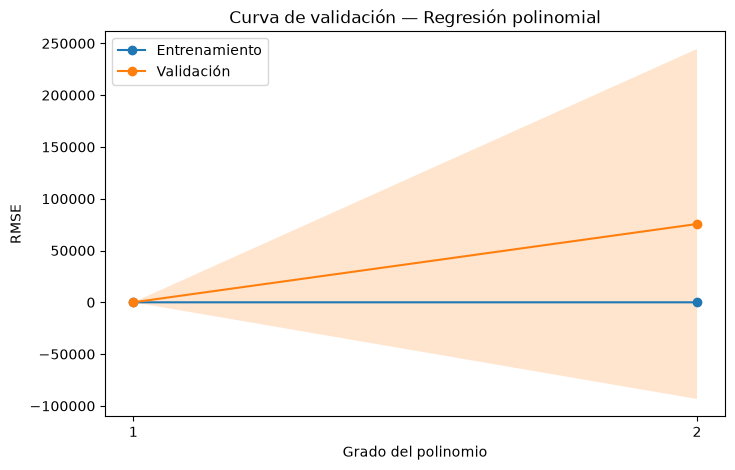

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(
    grados_curva,
    train_mean,
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    grados_curva,
    val_mean,
    marker="o",
    label="Validación"
)

plt.fill_between(
    grados_curva,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    grados_curva,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Curva de validación — Regresión polinomial")
plt.xticks(grados_curva)
plt.legend()
plt.show()


In [88]:
grado_sobreajuste_pablo = None

for i in range(1, len(grados_curva)):
    baja_train = train_mean.iloc[i] < train_mean.iloc[i - 1]
    sube_validacion = val_mean.iloc[i] > val_mean.iloc[i - 1]

    if baja_train and sube_validacion:
        grado_sobreajuste_pablo = grados_curva[i]
        break

if grado_sobreajuste_pablo is not None:
    print(
        "El sobreajuste empieza a evidenciarse en grado",
        grado_sobreajuste_pablo
    )
else:
    print(
        "Con los grados evaluados no se detectó automáticamente "
        "un punto de sobreajuste mediante este criterio."
    )


El sobreajuste empieza a evidenciarse en grado 2


### Interpretación del trade-off sesgo-varianza

Un modelo de grado bajo suele tener mayor sesgo y menor varianza. Al aumentar el grado, el modelo gana flexibilidad y puede reducir el error de entrenamiento, pero también aumenta su varianza.

Si el grado 2 reduce el RMSE de entrenamiento pero empeora el RMSE de validación respecto al grado 1, el aumento de complejidad está capturando ruido y no patrones que generalicen. Ese comportamiento corresponde a sobreajuste.


# Actividad 3 — Regresión lineal regularizada

Se comparan tres modelos:

1. **Regresión Lineal:** modelo base sin penalización.
2. **Ridge:** regularización L2, que penaliza la suma de los coeficientes al cuadrado.
3. **Lasso:** regularización L1, que puede reducir algunos coeficientes exactamente a cero y, por tanto, realizar selección automática de características.

La idea es estudiar si la regularización mejora la capacidad de generalización y la estabilidad del modelo.


### 3.1 Preprocesamiento

Las variables numéricas y categóricas requieren tratamientos distintos:

- Para variables numéricas se utiliza imputación por **mediana**, debido a que es menos sensible a valores extremos.
- Para variables categóricas se utiliza imputación por **moda** y posteriormente `OneHotEncoder`.
- El escalamiento se deja como hiperparámetro para que `GridSearchCV` compare:
  - `StandardScaler`
  - `MinMaxScaler`
  - sin escalamiento (`passthrough`)

Todo el preprocesamiento está dentro del pipeline para que cada fold de validación cruzada aprenda sus transformaciones únicamente con sus datos de entrenamiento.


In [89]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalador", "passthrough")
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            columnas_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            columnas_categoricas
        )
    ]
)

### 3.2 Modelos e hiperparámetros

Para la regresión lineal se explora únicamente la estrategia de escalamiento.

Para Ridge y Lasso también se explora el parámetro `alpha`, que controla la intensidad de la penalización:

- valores pequeños de `alpha` producen poca regularización;
- valores grandes producen una penalización más fuerte.

En Lasso se incrementa `max_iter` para dar suficiente tiempo al proceso de optimización y reducir problemas de convergencia.


In [90]:
pipeline_lineal = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", LinearRegression())
    ]
)

parametros_lineal = {
    "preprocesamiento__numericas__escalador": [
        StandardScaler(),
        MinMaxScaler(),
        "passthrough"
    ]
}

In [91]:
pipeline_ridge = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", Ridge())
    ]
)

parametros_ridge = {
    "preprocesamiento__numericas__escalador": [
        StandardScaler(),
        MinMaxScaler(),
        "passthrough"
    ],

    "modelo__alpha": [
        10,
        100,
        1000,
        10000,
        100000,
        1000000
    ]
}

In [92]:
pipeline_lasso = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            Lasso(max_iter=50000)
        )
    ]
)

parametros_lasso = {
    "preprocesamiento__numericas__escalador": [
        StandardScaler(),
        MinMaxScaler(),
        "passthrough"
    ],

    "modelo__alpha": [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000,
    10000
]
}

### 3.3 Métricas y validación cruzada

Se utilizan tres métricas:

- **RMSE:** penaliza con mayor fuerza los errores grandes. Es la métrica principal de selección.
- **MAE:** representa el error absoluto promedio.
- **R²:** mide la proporción de variabilidad explicada por el modelo.

`GridSearchCV` utiliza **5 folds**. Se configura `refit="rmse"` para que el mejor modelo sea el que obtenga el menor RMSE promedio en validación cruzada.


In [93]:
metricas = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [94]:
grid_lineal = GridSearchCV(
    estimator=pipeline_lineal,
    param_grid=parametros_lineal,
    scoring=metricas,
    refit="rmse",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

In [95]:
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=parametros_ridge,
    scoring=metricas,
    refit="rmse",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

In [96]:
grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=parametros_lasso,
    scoring=metricas,
    refit="rmse",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

### 3.4 Entrenamiento y selección de hiperparámetros

A continuación se ejecutan las búsquedas para los tres modelos. Cada combinación de hiperparámetros se evalúa en los cinco folds de validación cruzada.


In [97]:
grid_lineal.fit(X_train, y_train)

print("Lineal terminado")
print("Mejores parámetros:")
print(grid_lineal.best_params_)

grid_ridge.fit(X_train, y_train)

print("Ridge terminado")
print("Mejores parámetros:")
print(grid_ridge.best_params_)

grid_lasso.fit(X_train, y_train)

print("Lasso terminado")
print("Mejores parámetros:")
print(grid_lasso.best_params_)

Lineal terminado
Mejores parámetros:
{'preprocesamiento__numericas__escalador': MinMaxScaler()}
Ridge terminado
Mejores parámetros:
{'modelo__alpha': 10000, 'preprocesamiento__numericas__escalador': 'passthrough'}
Lasso terminado
Mejores parámetros:
{'modelo__alpha': 1, 'preprocesamiento__numericas__escalador': 'passthrough'}


In [98]:
print("LINEAL")
print(grid_lineal.best_params_)
print("CV RMSE:", -grid_lineal.best_score_)

print("\nRIDGE")
print(grid_ridge.best_params_)
print("CV RMSE:", -grid_ridge.best_score_)

print("\nLASSO")
print(grid_lasso.best_params_)
print("CV RMSE:", -grid_lasso.best_score_)

LINEAL
{'preprocesamiento__numericas__escalador': MinMaxScaler()}
CV RMSE: 16.365352539650306

RIDGE
{'modelo__alpha': 10000, 'preprocesamiento__numericas__escalador': 'passthrough'}
CV RMSE: 7.234864230330619

LASSO
{'modelo__alpha': 1, 'preprocesamiento__numericas__escalador': 'passthrough'}
CV RMSE: 6.689328485324277


### Resultados iniciales de validación cruzada

Los mejores hiperparámetros encontrados fueron:

- **Lineal:** `MinMaxScaler`.
- **Ridge:** `alpha = 10000`, sin escalamiento.
- **Lasso:** `alpha = 1`, sin escalamiento.

Los RMSE promedio de validación cruzada fueron aproximadamente:

- Lineal: **16.365**
- Ridge: **7.235**
- Lasso: **6.689**

Según validación cruzada, **Lasso obtiene el menor error promedio**.


### 3.5 Evaluación sobre el conjunto de test

Después de seleccionar los mejores hiperparámetros exclusivamente con validación cruzada, los modelos se evalúan una sola vez sobre `X_test`.

También se recupera la desviación estándar del RMSE entre folds (`CV STD`), porque un modelo adecuado no solo debe tener un error promedio bajo, sino mostrar un comportamiento estable entre distintas particiones de los datos.


In [99]:
def evaluar_test(nombre, grid):

    mejor_modelo = grid.best_estimator_

    y_pred = mejor_modelo.predict(X_test)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    indice = grid.best_index_

    cv_rmse = -grid.cv_results_[
        "mean_test_rmse"
    ][indice]

    cv_std = grid.cv_results_[
        "std_test_rmse"
    ][indice]

    return {
        "Modelo": nombre,
        "CV RMSE": cv_rmse,
        "CV STD": cv_std,
        "Test RMSE": rmse,
        "Test MAE": mae,
        "Test R2": r2
    }

In [100]:
resultado_lineal = evaluar_test(
    "Lineal",
    grid_lineal
)

resultado_ridge = evaluar_test(
    "Ridge",
    grid_ridge
)

resultado_lasso = evaluar_test(
    "Lasso",
    grid_lasso
)

resultados_actividad_3 = pd.DataFrame([
    resultado_lineal,
    resultado_ridge,
    resultado_lasso
])

display(resultados_actividad_3)

,Modelo,CV RMSE,CV STD,Test RMSE,Test MAE,Test R2
0,Lineal,16.365353,22.977546,4.786775,3.508448,0.722289
1,Ridge,7.234864,0.479669,7.007279,5.473854,0.404879
2,Lasso,6.689328,0.379133,6.575499,5.092170,0.475960


### Análisis comparativo de la Actividad 3

Los resultados muestran un comportamiento importante:

- **Regresión Lineal** obtiene el mejor resultado en el conjunto de test, con RMSE ≈ **4.787**, MAE ≈ **3.508** y R² ≈ **0.722**.
- Sin embargo, su RMSE promedio de validación cruzada es ≈ **16.365**, con una desviación estándar ≈ **22.978**. Esta variabilidad es extremadamente alta y evidencia que el modelo es muy sensible a la partición de los datos.
- **Ridge** obtiene CV RMSE ≈ **7.235** y CV STD ≈ **0.480**, mostrando una estabilidad muy superior al modelo lineal.
- **Lasso** obtiene el mejor desempeño promedio en validación cruzada, con CV RMSE ≈ **6.689** y CV STD ≈ **0.379**, siendo además el modelo más estable de los tres.

Por lo tanto, el mejor desempeño en un único conjunto de test **no coincide** con el mejor promedio de validación cruzada. Esto puede ocurrir porque el test particular puede resultar favorable para un modelo, mientras que la validación cruzada permite observar su comportamiento en varias particiones.

Considerando capacidad de generalización y estabilidad, **Lasso es el modelo más sólido de esta actividad**, aunque la regresión lineal haya obtenido una mejor métrica en este test específico.


### 3.6 Selección automática de características con Lasso

Una propiedad importante de la regularización L1 es que puede llevar coeficientes exactamente a cero. Cuando esto ocurre, la característica deja de participar en la predicción del modelo.

Se extraen los nombres de las variables transformadas y sus coeficientes para identificar cuáles fueron eliminadas por Lasso.


In [101]:
mejor_lasso = grid_lasso.best_estimator_

nombres_variables = mejor_lasso.named_steps[
    "preprocesamiento"
].get_feature_names_out()

coeficientes_lasso = mejor_lasso.named_steps[
    "modelo"
].coef_

tabla_lasso = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes_lasso
})

tabla_lasso["Eliminada"] = (
    tabla_lasso["Coeficiente"].abs() < 1e-8
)

tabla_lasso["Magnitud"] = (
    tabla_lasso["Coeficiente"].abs()
)

tabla_lasso = tabla_lasso.sort_values(
    "Magnitud",
    ascending=False
)

display(tabla_lasso)

,Variable,Coeficiente,Eliminada,Magnitud
24,categoricas__estacion_anio_verano,2.767747,False,2.767747
7,numericas__humedad_desv,0.568241,False,0.568241
3,numericas__presion_desv,-0.167762,False,0.167762
5,numericas__humedad_min,-0.093914,False,0.093914
6,numericas__humedad_max,-0.089860,False,0.089860
20,numericas__anio,0.076273,False,0.076273
4,numericas__humedad_media,-0.050530,False,0.050530
1,numericas__presion_min,0.020446,False,0.020446
21,numericas__dia_del_anio,0.018022,False,0.018022
11,numericas__viento_desv,0.005868,False,0.005868


In [102]:
print(
    "Total variables transformadas:",
    len(tabla_lasso)
)

print(
    "Variables llevadas a cero:",
    tabla_lasso["Eliminada"].sum()
)

Total variables transformadas: 43
Variables llevadas a cero: 30


### Interpretación de Lasso

El modelo Lasso trabajó con **43 características transformadas** y llevó **30 de ellas a coeficiente cero**, conservando únicamente 13.

Esto muestra una selección de características bastante fuerte. Entre las variables conservadas aparecen factores relacionados con:

- humedad;
- presión;
- viento;
- temporalidad;
- estación del año.

La característica `estacion_anio_verano` presenta el coeficiente de mayor magnitud positiva.

La selección realizada por Lasso mejora la interpretabilidad, pero un coeficiente cero **no significa necesariamente que una variable no tenga ninguna relación con la temperatura**. En presencia de variables correlacionadas, Lasso puede conservar una de ellas y eliminar otras que contienen información redundante.


# Actividad 4 — Regresión polinomial regularizada

En esta actividad se combinan características polinomiales con regularización Ridge.

`PolynomialFeatures` permite aumentar la complejidad del modelo creando potencias e interacciones entre características. Sin embargo, incrementar el grado también aumenta rápidamente el número de variables y puede producir:

- sobreajuste;
- alta varianza;
- multicolinealidad;
- mayor costo computacional.

Ridge se utiliza para penalizar la magnitud de los coeficientes y controlar parte de esa complejidad.


### 4.1 Pipeline polinomial

Primero se imputan las variables numéricas y categóricas. Luego:

1. se generan las características polinomiales;
2. se aplica la estrategia de escalamiento;
3. se ajusta un modelo Ridge.

El parámetro `sparse_threshold=0` fuerza una salida densa, necesaria para trabajar de manera consistente con las características polinomiales en este pipeline.


In [103]:
preprocesador_poly = ColumnTransformer(
    transformers=[
        (
            "numericas",
            SimpleImputer(strategy="median"),
            columnas_numericas
        ),
        (
            "categoricas",
            Pipeline(
                steps=[
                    (
                        "imputacion",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            drop="first"
                        )
                    )
                ]
            ),
            columnas_categoricas
        )
    ],
    sparse_threshold=0
)

pipeline_poly_ridge = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_poly
        ),
        (
            "polinomio",
            PolynomialFeatures(
                include_bias=False
            )
        ),
        (
            "escalador",
            StandardScaler()
        ),
        (
            "modelo",
            Ridge()
        )
    ]
)

### 4.2 Búsqueda de hiperparámetros

El `GridSearchCV` explora simultáneamente:

- grado del polinomio: **1 y 2**;
- estrategia de escalamiento;
- intensidad de regularización `alpha`.

Se limita inicialmente el grado a 2 porque el número de características crece rápidamente con la expansión polinomial, aumentando significativamente el costo computacional y el riesgo de sobreajuste.


In [104]:
parametros_poly_ridge = {
    "polinomio__degree": [
        1,
        2
    ],

    "escalador": [
        StandardScaler(),
        MinMaxScaler(),
        "passthrough"
    ],

    "modelo__alpha": [
    0.01,
    0.1,
    1,
    10,
    100,
    1000,
    10000,
    100000
]
}

### 4.3 Entrenamiento

Durante algunas combinaciones pueden aparecer advertencias de matriz mal condicionada (`LinAlgWarning`). Esto es consistente con la creación de muchas características correlacionadas mediante `PolynomialFeatures`.

La búsqueda no se interrumpe por estas advertencias; Ridge ayuda precisamente a estabilizar modelos con fuerte correlación entre predictores.


In [105]:
grid_poly_ridge = GridSearchCV(
    estimator=pipeline_poly_ridge,
    param_grid=parametros_poly_ridge,
    scoring=metricas,
    refit="rmse",
    cv=5,
    n_jobs=2,
    return_train_score=True
)

grid_poly_ridge.fit(
    X_train,
    y_train
)

/Users/santiagoserranoperico/Desktop/Universidad/2026-2/aprendizaje/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.2977605545730507e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/santiagoserranoperico/Desktop/Universidad/2026-2/aprendizaje/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.116521015449157e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/santiagoserranoperico/Desktop/Universidad/2026-2/aprendizaje/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.210887410928384e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/santiagoserranoperico/Desktop/Universidad/2026-2/aprendizaje/.venv/lib/python3.14/site-packages/sk

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'escalador': [StandardScaler(), MinMaxScaler(), ...], 'modelo__alpha': [0.01, 0.1, ...], 'polinomio__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'rmse'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchang

In [106]:
print("Mejores parámetros:")
print(grid_poly_ridge.best_params_)

print(
    "CV RMSE:",
    -grid_poly_ridge.best_score_
)

Mejores parámetros:
{'escalador': 'passthrough', 'modelo__alpha': 10000, 'polinomio__degree': 1}
CV RMSE: 7.234864230330619


### Resultado de la búsqueda polinomial regularizada

La mejor configuración encontrada fue:

- **grado = 1**
- **alpha = 10000**
- **sin escalamiento (`passthrough`)**

El CV RMSE obtenido fue aproximadamente **7.235**.

El resultado más relevante es que el GridSearch seleccionó **grado 1**. Esto indica que introducir términos polinomiales de grado 2 no mejoró la capacidad de generalización del modelo.

Como un polinomio de grado 1 conserva únicamente relaciones lineales, esta configuración se vuelve esencialmente equivalente al mejor modelo Ridge encontrado en la Actividad 3. Por eso ambos modelos presentan métricas prácticamente idénticas.


In [107]:
resultado_poly_ridge = evaluar_test(
    "Polinomial + Ridge",
    grid_poly_ridge
)

resultado_poly_ridge

{'Modelo': 'Polinomial + Ridge',
 'CV RMSE': np.float64(7.234864230330619),
 'CV STD': np.float64(0.47966867477179187),
 'Test RMSE': 7.007278550414392,
 'Test MAE': 5.4738536028600695,
 'Test R2': 0.40487891479045934}

In [108]:
resultados_santiago = pd.DataFrame([
    resultado_lineal,
    resultado_ridge,
    resultado_lasso,
    resultado_poly_ridge
])

display(
    resultados_santiago.sort_values(
        "CV RMSE"
    )
)

,Modelo,CV RMSE,CV STD,Test RMSE,Test MAE,Test R2
2,Lasso,6.689328,0.379133,6.575499,5.092170,0.475960
1,Ridge,7.234864,0.479669,7.007279,5.473854,0.404879
3,Polinomial + Ridge,7.234864,0.479669,7.007279,5.473854,0.404879
0,Lineal,16.365353,22.977546,4.786775,3.508448,0.722289


# Conclusiones de las Actividades 3 y 4

Los resultados permiten extraer varias conclusiones:

1. **La regularización mejora notablemente la estabilidad.**  
   La regresión lineal simple obtuvo un excelente resultado en el test particular, pero presentó una variabilidad muy alta en validación cruzada.

2. **Lasso presenta el mejor equilibrio entre desempeño y estabilidad.**  
   Obtuvo el menor CV RMSE y la menor desviación estándar entre los modelos evaluados en la Actividad 3.

3. **Lasso mejora la interpretabilidad.**  
   Eliminó 30 de 43 características transformadas mediante coeficientes iguales a cero.

4. **Mayor complejidad no produjo una mejora automática.**  
   En la Actividad 4, el mejor modelo polinomial regularizado seleccionó grado 1, indicando que los términos de grado 2 no aportaron una mejora en generalización.

5. **Polinomial + Ridge y Ridge terminaron siendo equivalentes.**  
   Esto ocurre porque `degree=1` no añade términos de orden superior. Por esta razón coinciden sus mejores hiperparámetros y sus métricas.

6. **El mejor modelo no debe seleccionarse únicamente por un único test.**  
   La gran diferencia entre el desempeño de la regresión lineal en test y su alta variabilidad en validación cruzada muestra la importancia de considerar simultáneamente desempeño promedio y estabilidad.

Estos resultados deberán integrarse posteriormente con el modelo polinomial desarrollado en la Actividad 1 para realizar la selección conjunta del mejor modelo en la Actividad 5.


# Actividad 5 — Comparación y selección del mejor modelo

Se integran los resultados de las Actividades 1, 3 y 4.

El criterio principal es el **RMSE promedio en validación cruzada**, acompañado de su desviación estándar. El test se utiliza como verificación final.

No se selecciona automáticamente un modelo solo porque obtenga el menor error en un único test: también se consideran estabilidad, complejidad e interpretabilidad.


In [109]:
resultados_finales = pd.concat(
    [
        resultados_santiago,
        pd.DataFrame([resultado_pablo])
    ],
    ignore_index=True
)

resultados_finales["CV RMSE + 1STD"] = (
    resultados_finales["CV RMSE"] +
    resultados_finales["CV STD"]
)

resultados_finales = resultados_finales.sort_values(
    ["CV RMSE", "CV STD"],
    ascending=[True, True]
).reset_index(drop=True)

display(resultados_finales)


,Modelo,CV RMSE,CV STD,Test RMSE,Test MAE,Test R2,CV RMSE + 1STD
0,Lasso,6.689328,0.379133,6.575499,5.092170,0.475960,7.068462
1,Ridge,7.234864,0.479669,7.007279,5.473854,0.404879,7.714533
2,Polinomial + Ridge,7.234864,0.479669,7.007279,5.473854,0.404879,7.714533
3,Lineal,16.365353,22.977546,4.786775,3.508448,0.722289,39.342899
4,Polinomial sin regularización,16.365353,22.977546,4.786775,3.508448,0.722289,39.342899


In [110]:
modelos_candidatos = {
    "Lineal": grid_lineal.best_estimator_,
    "Ridge": grid_ridge.best_estimator_,
    "Lasso": grid_lasso.best_estimator_,
    "Polinomial + Ridge": grid_poly_ridge.best_estimator_,
    "Polinomial sin regularización": grid_pablo.best_estimator_
}

fila_ganadora = resultados_finales.iloc[0]
nombre_ganador = fila_ganadora["Modelo"]
modelo_ganador = modelos_candidatos[nombre_ganador]

print("Modelo seleccionado:", nombre_ganador)
print("CV RMSE:", fila_ganadora["CV RMSE"])
print("CV STD:", fila_ganadora["CV STD"])
print("Test RMSE:", fila_ganadora["Test RMSE"])
print("Test MAE:", fila_ganadora["Test MAE"])
print("Test R²:", fila_ganadora["Test R2"])


Modelo seleccionado: Lasso
CV RMSE: 6.689328485324277
CV STD: 0.37913325950329163
Test RMSE: 6.575499424573812
Test MAE: 5.092170378469149
Test R²: 0.4759604532077417


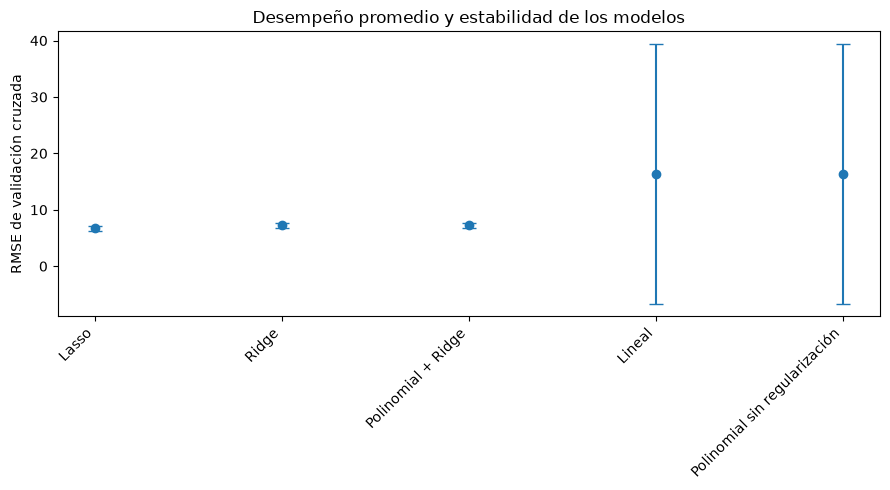

In [111]:
# Comparación visual del desempeño y estabilidad

plt.figure(figsize=(9, 5))

plt.errorbar(
    resultados_finales["Modelo"],
    resultados_finales["CV RMSE"],
    yerr=resultados_finales["CV STD"],
    fmt="o",
    capsize=5
)

plt.ylabel("RMSE de validación cruzada")
plt.title("Desempeño promedio y estabilidad de los modelos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Actividad 6 — Intervalos de confianza mediante bootstrapping

Se realizan **1000 remuestreos con reemplazo** sobre el conjunto de test del modelo ganador.

Primero se construye una tabla con el valor real y la predicción de cada observación. En cada repetición se toma una nueva muestra del mismo tamaño, permitiendo repetir filas, y se vuelven a calcular RMSE, MAE y R².

Finalmente, los percentiles 2.5% y 97.5% de las 1000 métricas obtenidas forman el intervalo de confianza del 95%.

Este procedimiento permite medir cuánto varía el desempeño del modelo si cambia la muestra de observaciones evaluadas.


In [112]:
def bootstrap_metricas(modelo, X_test, y_test, repeticiones=1000):

    # Predicciones del modelo ganador sobre el conjunto de test
    predicciones = modelo.predict(X_test)

    # Unimos valores reales y predichos en una sola tabla
    datos_test = pd.DataFrame({
        "Real": y_test.reset_index(drop=True),
        "Prediccion": predicciones
    })

    resultados = []

    # Creamos nuevas muestras con reemplazo
    for i in range(repeticiones):

        muestra = datos_test.sample(
            n=len(datos_test),
            replace=True,
            random_state=i
        )

        rmse = mean_squared_error(
            muestra["Real"],
            muestra["Prediccion"]
        ) ** 0.5

        mae = mean_absolute_error(
            muestra["Real"],
            muestra["Prediccion"]
        )

        r2 = r2_score(
            muestra["Real"],
            muestra["Prediccion"]
        )

        resultados.append([rmse, mae, r2])

    return pd.DataFrame(
        resultados,
        columns=["RMSE", "MAE", "R2"]
    )


bootstrap_df = bootstrap_metricas(
    modelo_ganador,
    X_test,
    y_test,
    repeticiones=1000
)

display(bootstrap_df.describe())


,RMSE,MAE,R2
count,1000.000000,1000.000000,1000.000000
mean,6.572173,5.087307,0.474885
std,0.284524,0.168506,0.035005
min,5.714977,4.620384,0.377209
25%,6.376418,4.970598,0.450719
50%,6.561881,5.087428,0.475078
75%,6.758657,5.196524,0.499025
max,7.426360,5.613578,0.575501


In [113]:
def intervalo_95(valores):
    inferior = valores.quantile(0.025)
    superior = valores.quantile(0.975)

    return inferior, superior


rmse_inf, rmse_sup = intervalo_95(bootstrap_df["RMSE"])
mae_inf, mae_sup = intervalo_95(bootstrap_df["MAE"])
r2_inf, r2_sup = intervalo_95(bootstrap_df["R2"])

resumen_ic = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²"],
    "Media bootstrap": [
        bootstrap_df["RMSE"].mean(),
        bootstrap_df["MAE"].mean(),
        bootstrap_df["R2"].mean()
    ],
    "IC 95% inferior": [
        rmse_inf,
        mae_inf,
        r2_inf
    ],
    "IC 95% superior": [
        rmse_sup,
        mae_sup,
        r2_sup
    ]
})

display(resumen_ic)


,Métrica,Media bootstrap,IC 95% inferior,IC 95% superior
0,RMSE,6.572173,6.042180,7.137890
1,MAE,5.087307,4.764127,5.429604
2,R²,0.474885,0.406186,0.545752


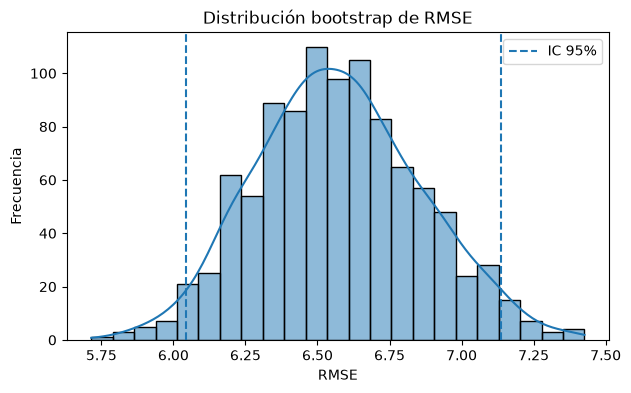

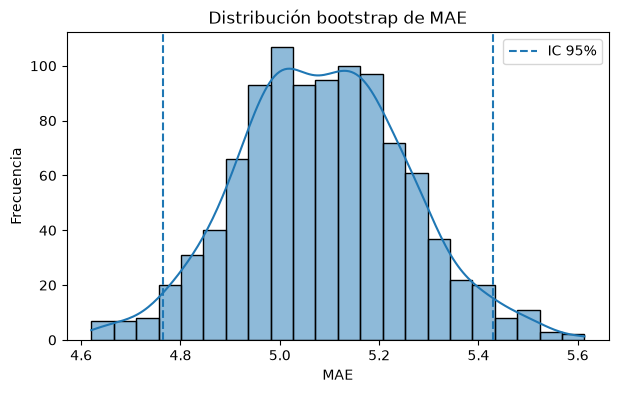

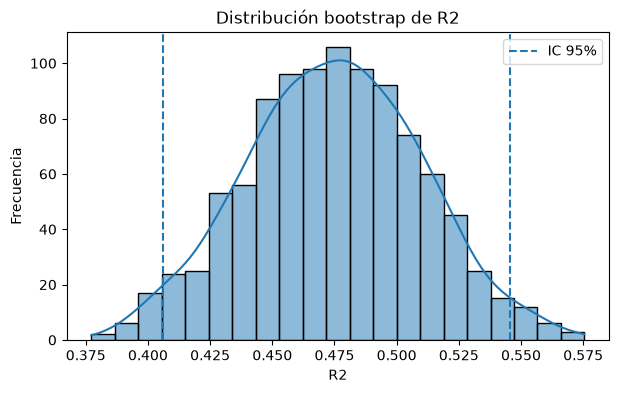

In [114]:
for metrica in ["RMSE", "MAE", "R2"]:

    inferior, superior = intervalo_95(
        bootstrap_df[metrica]
    )

    plt.figure(figsize=(7, 4))

    sns.histplot(
        bootstrap_df[metrica],
        kde=True
    )

    plt.axvline(
        inferior,
        linestyle="--",
        label="IC 95%"
    )

    plt.axvline(
        superior,
        linestyle="--"
    )

    plt.title(
        f"Distribución bootstrap de {metrica}"
    )

    plt.xlabel(metrica)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()


### Interpretación del bootstrap

El bootstrapping no modifica ni vuelve a entrenar el modelo. Lo que cambia en cada repetición es la muestra de observaciones de test utilizada para calcular las métricas.

Si las distribuciones de RMSE, MAE y R² están concentradas y los intervalos de confianza son relativamente estrechos, el desempeño del modelo es estable frente a cambios en la muestra. Si las distribuciones son muy dispersas, existe mayor incertidumbre sobre el rendimiento esperado.


# Análisis de resultados


In [115]:
ic_rmse = intervalo_95(
    bootstrap_df["RMSE"]
)

ic_mae = intervalo_95(
    bootstrap_df["MAE"]
)

ic_r2 = intervalo_95(
    bootstrap_df["R2"]
)

variables_lasso = tabla_lasso.loc[
    ~tabla_lasso["Eliminada"],
    "Variable"
].tolist()

if grado_sobreajuste_pablo is None:
    texto_sobreajuste = (
        "Con los grados evaluados no se detectó automáticamente "
        "un incremento simultáneo de generalización y reducción de "
        "entrenamiento mediante el criterio programado. La gráfica "
        "debe utilizarse para complementar esta interpretación."
    )
else:
    texto_sobreajuste = (
        f"El sobreajuste comienza a evidenciarse en el grado "
        f"{grado_sobreajuste_pablo}: el error de entrenamiento "
        f"disminuye mientras el error de validación aumenta."
    )

display(Markdown(f'''
## Análisis cuantitativo

### ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

Según la columna **Test RMSE**, el menor error en el conjunto de test corresponde a:

**{resultados_finales.sort_values("Test RMSE").iloc[0]["Modelo"]}**

con RMSE de aproximadamente **{resultados_finales.sort_values("Test RMSE").iloc[0]["Test RMSE"]:.3f}**.

Sin embargo, el modelo seleccionado para generalización fue **{nombre_ganador}**, porque obtuvo el mejor balance entre RMSE promedio de validación cruzada y estabilidad.

### ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada?

{"Sí." if resultados_finales.sort_values("Test RMSE").iloc[0]["Modelo"] == nombre_ganador else "No."}

Esto demuestra por qué no es conveniente elegir un modelo únicamente por una partición de test. La validación cruzada evalúa distintas particiones y permite medir estabilidad.

### ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

No siempre. Además del RMSE promedio deben considerarse su desviación estándar, la complejidad, la interpretabilidad y el costo computacional. En este laboratorio se prioriza un modelo con error bajo y comportamiento consistente entre folds.

### ¿Cómo cambia el error a medida que aumenta la complejidad?

{texto_sobreajuste}

Esto refleja el trade-off sesgo-varianza: aumentar la complejidad puede reducir sesgo, pero eleva la varianza y puede deteriorar la generalización.

### ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

Ridge reduce la magnitud de los coeficientes mediante penalización L2. Lasso utiliza penalización L1 y puede llevar coeficientes exactamente a cero. En los resultados obtenidos, los modelos regularizados presentaron una validación cruzada mucho más estable que la regresión lineal base.

### ¿Qué indican los intervalos de confianza?

Para **{nombre_ganador}**:

- RMSE IC 95%: **[{ic_rmse[0]:.3f}, {ic_rmse[1]:.3f}]**
- MAE IC 95%: **[{ic_mae[0]:.3f}, {ic_mae[1]:.3f}]**
- R² IC 95%: **[{ic_r2[0]:.3f}, {ic_r2[1]:.3f}]**

La amplitud de estos intervalos cuantifica la incertidumbre del desempeño. Intervalos más estrechos indican mayor estabilidad frente a cambios en la muestra de test.


## Análisis cualitativo

### ¿Qué variables fueron seleccionadas como más relevantes por Lasso?

Lasso conservó **{len(variables_lasso)}** características transformadas y llevó las demás a cero.

Las variables conservadas fueron:

`{", ".join(variables_lasso)}`

Esto representa selección automática de características mediante regularización L1.

### ¿Qué interpretación práctica tienen los coeficientes del modelo final?

El signo indica la dirección de la asociación con la temperatura máxima predicha, manteniendo constantes las demás variables. La magnitud debe interpretarse considerando escalamiento y regularización. Los coeficientes describen asociaciones predictivas, no causalidad.

### ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Sí. Un modelo puede lograr mejor RMSE en un test específico pero ser inestable entre folds. Lasso ofrece una ventaja de interpretabilidad al eliminar características, mientras otros modelos pueden conservar muchas variables.

### ¿Qué decisiones estratégicas podría tomar AlpesPlanck?

AlpesPlanck puede:

- priorizar sensores asociados a variables predictivamente relevantes;
- anticipar jornadas con temperaturas máximas elevadas;
- usar intervalos de incertidumbre para evitar decisiones basadas en un único valor puntual;
- preferir modelos estables cuando se requiera operación repetida en datos futuros.

### ¿Mayor precisión implica necesariamente mayor valor?

No. Una mejora marginal en precisión puede no justificar menor interpretabilidad, mayor inestabilidad o mayor costo computacional.

### ¿Un modelo más complejo necesariamente genera mayor valor?

No. En este laboratorio, aumentar el grado polinomial puede aumentar el sobreajuste. Además, el modelo polinomial regularizado de Santiago seleccionó grado 1, mostrando que más complejidad no produjo mejor generalización.


## Reflexión conceptual

### ¿Qué relación existe entre complejidad, generalización y estabilidad?

Aumentar complejidad reduce potencialmente el sesgo pero aumenta la varianza. La regularización controla esta varianza penalizando coeficientes grandes. El objetivo no es maximizar complejidad, sino encontrar el punto con mejor generalización.

### ¿Qué fuentes de sesgo podrían existir?

Pueden existir:

- errores o sesgo de medición en sensores;
- sesgo temporal;
- diferencias entre condiciones meteorológicas históricas y futuras;
- sesgo de representación;
- efectos derivados de decisiones de limpieza, imputación y selección de variables.

### Si el tamaño de muestra fuera mayor, ¿cambiaría la estabilidad?

En general, sí. Con más observaciones los parámetros y las métricas tienden a depender menos de muestras particulares, reduciendo varianza y permitiendo evaluar modelos más complejos de manera más confiable. Sin embargo, aumentar el tamaño no elimina sesgos sistemáticos de medición o representación.
'''))



## Análisis cuantitativo

### ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

Según la columna **Test RMSE**, el menor error en el conjunto de test corresponde a:

**Lineal**

con RMSE de aproximadamente **4.787**.

Sin embargo, el modelo seleccionado para generalización fue **Lasso**, porque obtuvo el mejor balance entre RMSE promedio de validación cruzada y estabilidad.

### ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada?

No.

Esto demuestra por qué no es conveniente elegir un modelo únicamente por una partición de test. La validación cruzada evalúa distintas particiones y permite medir estabilidad.

### ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

No siempre. Además del RMSE promedio deben considerarse su desviación estándar, la complejidad, la interpretabilidad y el costo computacional. En este laboratorio se prioriza un modelo con error bajo y comportamiento consistente entre folds.

### ¿Cómo cambia el error a medida que aumenta la complejidad?

El sobreajuste comienza a evidenciarse en el grado 2: el error de entrenamiento disminuye mientras el error de validación aumenta.

Esto refleja el trade-off sesgo-varianza: aumentar la complejidad puede reducir sesgo, pero eleva la varianza y puede deteriorar la generalización.

### ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

Ridge reduce la magnitud de los coeficientes mediante penalización L2. Lasso utiliza penalización L1 y puede llevar coeficientes exactamente a cero. En los resultados obtenidos, los modelos regularizados presentaron una validación cruzada mucho más estable que la regresión lineal base.

### ¿Qué indican los intervalos de confianza?

Para **Lasso**:

- RMSE IC 95%: **[6.042, 7.138]**
- MAE IC 95%: **[4.764, 5.430]**
- R² IC 95%: **[0.406, 0.546]**

La amplitud de estos intervalos cuantifica la incertidumbre del desempeño. Intervalos más estrechos indican mayor estabilidad frente a cambios en la muestra de test.


## Análisis cualitativo

### ¿Qué variables fueron seleccionadas como más relevantes por Lasso?

Lasso conservó **13** características transformadas y llevó las demás a cero.

Las variables conservadas fueron:

`categoricas__estacion_anio_verano, numericas__humedad_desv, numericas__presion_desv, numericas__humedad_min, numericas__humedad_max, numericas__anio, numericas__humedad_media, numericas__presion_min, numericas__dia_del_anio, numericas__viento_desv, numericas__viento_max, numericas__rafaga_desv, numericas__direccion_viento`

Esto representa selección automática de características mediante regularización L1.

### ¿Qué interpretación práctica tienen los coeficientes del modelo final?

El signo indica la dirección de la asociación con la temperatura máxima predicha, manteniendo constantes las demás variables. La magnitud debe interpretarse considerando escalamiento y regularización. Los coeficientes describen asociaciones predictivas, no causalidad.

### ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Sí. Un modelo puede lograr mejor RMSE en un test específico pero ser inestable entre folds. Lasso ofrece una ventaja de interpretabilidad al eliminar características, mientras otros modelos pueden conservar muchas variables.

### ¿Qué decisiones estratégicas podría tomar AlpesPlanck?

AlpesPlanck puede:

- priorizar sensores asociados a variables predictivamente relevantes;
- anticipar jornadas con temperaturas máximas elevadas;
- usar intervalos de incertidumbre para evitar decisiones basadas en un único valor puntual;
- preferir modelos estables cuando se requiera operación repetida en datos futuros.

### ¿Mayor precisión implica necesariamente mayor valor?

No. Una mejora marginal en precisión puede no justificar menor interpretabilidad, mayor inestabilidad o mayor costo computacional.

### ¿Un modelo más complejo necesariamente genera mayor valor?

No. En este laboratorio, aumentar el grado polinomial puede aumentar el sobreajuste. Además, el modelo polinomial regularizado de Santiago seleccionó grado 1, mostrando que más complejidad no produjo mejor generalización.


## Reflexión conceptual

### ¿Qué relación existe entre complejidad, generalización y estabilidad?

Aumentar complejidad reduce potencialmente el sesgo pero aumenta la varianza. La regularización controla esta varianza penalizando coeficientes grandes. El objetivo no es maximizar complejidad, sino encontrar el punto con mejor generalización.

### ¿Qué fuentes de sesgo podrían existir?

Pueden existir:

- errores o sesgo de medición en sensores;
- sesgo temporal;
- diferencias entre condiciones meteorológicas históricas y futuras;
- sesgo de representación;
- efectos derivados de decisiones de limpieza, imputación y selección de variables.

### Si el tamaño de muestra fuera mayor, ¿cambiaría la estabilidad?

En general, sí. Con más observaciones los parámetros y las métricas tienden a depender menos de muestras particulares, reduciendo varianza y permitiendo evaluar modelos más complejos de manera más confiable. Sin embargo, aumentar el tamaño no elimina sesgos sistemáticos de medición o representación.


# Conclusiones

1. La validación cruzada es fundamental para diferenciar desempeño puntual de estabilidad.
2. La regresión polinomial permite estudiar el efecto de aumentar complejidad, pero grados mayores pueden provocar sobreajuste.
3. Ridge y Lasso reducen la inestabilidad al penalizar los coeficientes.
4. Lasso agrega interpretabilidad mediante selección automática de características.
5. El modelo polinomial regularizado mostró que una mayor complejidad no garantiza mejor generalización.
6. La selección final considera simultáneamente RMSE promedio, desviación estándar, test, complejidad e interpretabilidad.
7. El bootstrapping permite cuantificar la incertidumbre del modelo ganador mediante intervalos de confianza.


# Uso de herramientas de IA generativa

## Declaración de uso

Se utilizó **ChatGPT** como apoyo para:

- aclaración conceptual;
- generación y estructuración inicial de pipelines;
- depuración de errores;
- revisión metodológica;
- organización del análisis;
- integración de los notebooks del equipo;
- mejora de redacción técnica.

## Prompts principales

Entre las consultas principales estuvieron:

- cómo estructurar Ridge y Lasso con `GridSearchCV`;
- cómo comparar estrategias de escalamiento;
- cómo interpretar RMSE, MAE, R² y desviación estándar;
- cómo identificar variables llevadas a cero por Lasso;
- cómo construir un modelo polinomial regularizado;
- cómo construir curvas de validación para detectar sobreajuste;
- cómo implementar bootstrap con al menos 500 remuestreos;
- cómo integrar los modelos del equipo usando una misma partición de datos.

## Análisis crítico

Las propuestas de IA no se aceptaron automáticamente. Se detectó que los primeros notebooks del equipo utilizaban procesos de limpieza y tamaños de muestra distintos, lo cual impedía una comparación justa. Por ello, se decidió unificar los modelos sobre el mismo CSV limpio y el mismo split.

También se ampliaron rangos de `alpha` cuando los mejores valores se encontraban en los límites de las búsquedas y se corrigió la diferencia conceptual entre validación cruzada, curvas de validación y bootstrapping.

